## Comparison by difficulty

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "/Data/allegra-maria-pia.boustany/llm_cross_eval/results/exp1_turn1_Qwen3-4B-Thinking-2507_vs_Qwen3-30B-A3B-Thinking-2507_1768301480.csv"
df = pd.read_csv(csv_path)

# safe log transform
df["ratio"] = df["ratio_pA_over_pB"].clip(lower=1e-30)
df["log10_ratio"] = np.log10(df["ratio"])
df["abs_log10_ratio"] = df["log10_ratio"].abs()

df.head()


,seed,example_id,bucket,level,prompt,continuation_text,token_idx,token_id,token_str,p_a,p_b,ratio_pA_over_pB,ratio,log10_ratio,abs_log10_ratio
0,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,0,1249,To,0.917652,0.862054,1.064494,1.064494,0.027143,0.027143
1,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,1,1477,find,0.939413,0.861212,1.090803,1.090803,0.037746,0.037746
2,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,2,279,the,0.997105,0.999594,0.997510,0.997510,-0.001083,0.001083
3,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,3,24632,smallest,0.999898,0.991068,1.008910,1.008910,0.003852,0.003852
4,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,4,5248,multiple,0.999989,0.999969,1.000020,1.000020,0.000009,0.000009


In [3]:
group_cols = ["seed", "example_id", "bucket", "level"]

per_problem = df.groupby(group_cols).agg(
    n_tokens=("token_idx", "count"),
    mean_abs_log10=("abs_log10_ratio", "mean"),
    p95_abs_log10=("abs_log10_ratio", lambda x: np.percentile(x, 95)),
    max_abs_log10=("abs_log10_ratio", "max"),
).reset_index()

per_problem.sort_values(["bucket","level","p95_abs_log10"], ascending=[True, True, False]).head(15)


,seed,example_id,bucket,level,n_tokens,mean_abs_log10,p95_abs_log10,max_abs_log10
0,42,test_105,easy,1,500,0.111936,0.624956,1.713427
11,42,test_466,easy,1,500,0.106008,0.587400,4.003652
8,42,test_3927,easy,1,500,0.091209,0.454822,2.341119
9,42,test_4371,easy,2,500,0.110162,0.665586,3.657574
3,42,test_1542,easy,2,500,0.074562,0.401553,1.621818
2,42,test_1416,easy,2,500,0.060625,0.373858,1.560746
6,42,test_267,hard,5,500,0.079819,0.471786,2.731305
7,42,test_3110,hard,5,500,0.068860,0.422207,3.196136
5,42,test_257,hard,5,500,0.071171,0.357614,3.945973
14,42,test_933,medium,3,500,0.173142,0.814504,5.444797


/tmp/ipykernel_3178734/3875310396.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order)


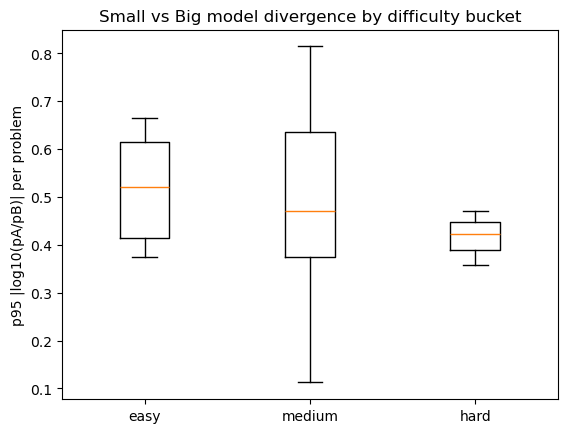

In [4]:
order = ["easy", "medium", "hard"]
data = [per_problem.loc[per_problem["bucket"]==b, "p95_abs_log10"].values for b in order]

plt.figure()
plt.boxplot(data, labels=order)
plt.ylabel("p95 |log10(pA/pB)| per problem")
plt.title("Small vs Big model divergence by difficulty bucket")
plt.show()


## Scaling up: 30 pbs per difficulty level

/tmp/ipykernel_3178734/3169733363.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data2, labels=order)


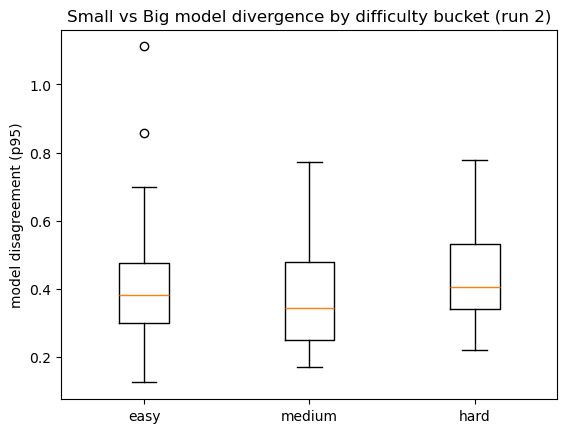

In [36]:
csv_path_2 = "/Data/allegra-maria-pia.boustany/llm_cross_eval/results/exp1_turn1_Qwen3-4B-Thinking-2507_vs_Qwen3-30B-A3B-Thinking-2507_1768516569.csv"
df2 = pd.read_csv(csv_path_2)

df2["ratio"] = df2["ratio_pA_over_pB"].clip(lower=1e-30)
df2["log10_ratio"] = np.log10(df2["ratio"])
df2["abs_log10_ratio"] = df2["log10_ratio"].abs()

per_problem_2 = df2.groupby(group_cols).agg(
    n_tokens=("token_idx", "count"),
    mean_abs_log10=("abs_log10_ratio", "mean"),
    p95_abs_log10=("abs_log10_ratio", lambda x: np.percentile(x, 95)),
    max_abs_log10=("abs_log10_ratio", "max"),
).reset_index()

data2 = [per_problem_2.loc[per_problem_2["bucket"]==b, "p95_abs_log10"].values for b in order]
plt.figure()
plt.boxplot(data2, labels=order)
plt.ylabel("model disagreement (p95)")
plt.title("Small vs Big model divergence by difficulty bucket (run 2)")
plt.show()



Ignoring the worst 5% of tokens, how large is the disagreement between the models on a problem ? 

Hypothesis: 

Observations: 




In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# df has ratio_pA_over_pB already
eps = 1e-30
df2 = df2.copy()
df2["ratio"] = df2["ratio_pA_over_pB"].clip(lower=eps)
df2["log_ratio"] = np.log(df2["ratio"])           # natural log
df2["abs_log_ratio"] = df2["log_ratio"].abs()

In [18]:
group_cols = ["seed", "example_id", "bucket", "level"]

per_problem = (
    df2.groupby(group_cols)
      .agg(
          n_tokens=("token_idx", "count"),
          p95_abs_log=("abs_log_ratio", lambda x: np.percentile(x, 95)),
          max_abs_log=("abs_log_ratio", "max"),
      )
      .reset_index()
)

# choose 1 example per bucket: "most divergent" by p95
rep = (
    per_problem.sort_values(["bucket", "p95_abs_log"], ascending=[True, False])
               .groupby("bucket", as_index=False)
               .head(1)
)
rep

,seed,example_id,bucket,level,n_tokens,p95_abs_log,max_abs_log
105,42,test_4332,easy,2,100,2.559570,6.765625
141,42,test_866,hard,5,100,1.790625,7.195312
31,42,test_1990,medium,3,100,1.779907,3.640625


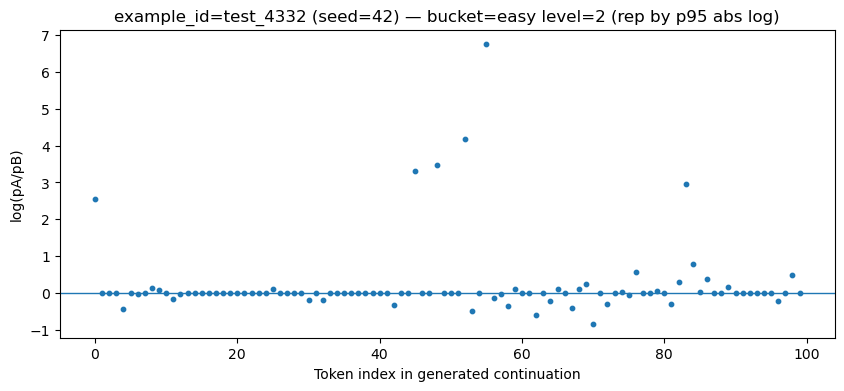

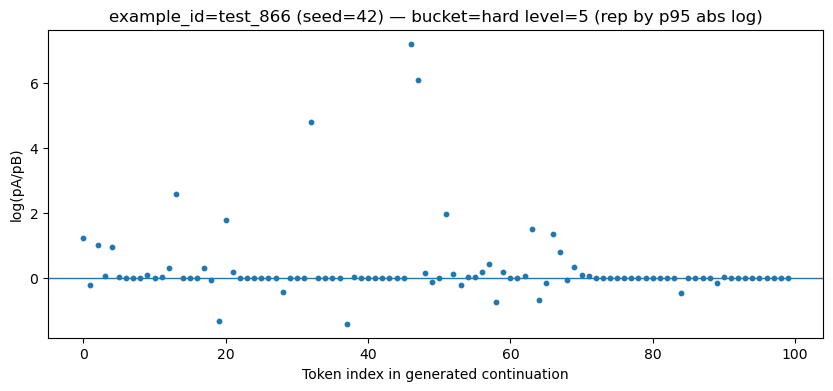

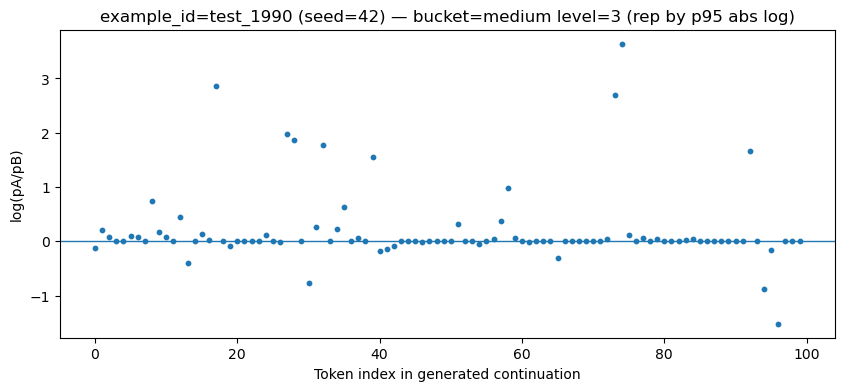

In [19]:
def plot_example_token_scatter(df, seed, example_id, title_suffix=""):
    g = df2[(df.seed == seed) & (df.example_id == example_id)].sort_values("token_idx")
    plt.figure(figsize=(10, 4))
    plt.scatter(g["token_idx"], g["log_ratio"], s=10)
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("Token index in generated continuation")
    plt.ylabel("log(pA/pB)")
    plt.title(f"example_id={example_id} (seed={seed}) {title_suffix}")
    plt.show()

for _, row in rep.iterrows():
    plot_example_token_scatter(
        df2,
        seed=row["seed"],
        example_id=row["example_id"],
        title_suffix=f"— bucket={row['bucket']} level={row['level']} (rep by p95 abs log)"
    )


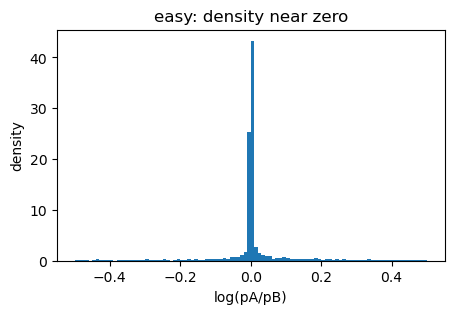

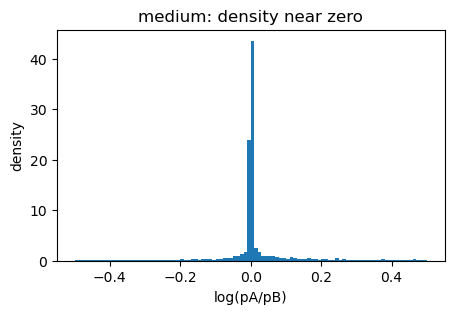

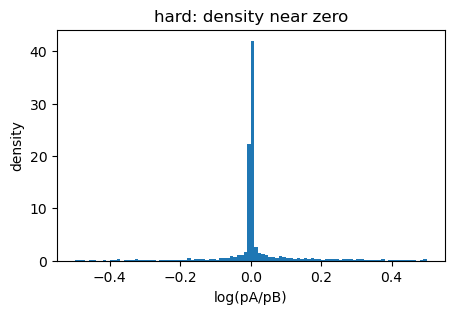

In [35]:
for bucket in ["easy","medium","hard"]:
    g = df2[df2.bucket == bucket]["log_ratio"]
    plt.figure(figsize=(5,3))
    plt.hist(g, bins=100, range=(-0.5,0.5), density=True)
    plt.title(f"{bucket}: density near zero")
    plt.xlabel("log(pA/pB)")
    plt.ylabel("density")
    plt.show()

In [31]:
import numpy as np

df2 = df2.copy()

# spike definition
SPIKE_THR = 2.0  # log-scale, took 2 because of previous discussions
df2["is_spike"] = df2["abs_log_ratio"] >= SPIKE_THR
# normalize token position per (seed, example)
df2["max_token"] = df2.groupby(["seed","example_id"])["token_idx"].transform("max")
df2["rel_pos"] = df2["token_idx"] / df2["max_token"]

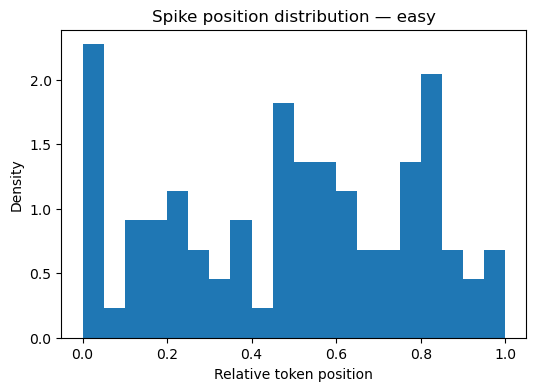

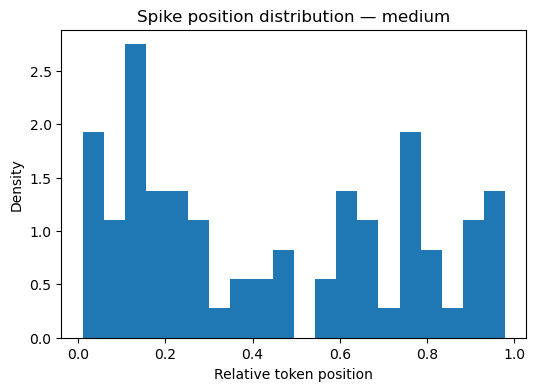

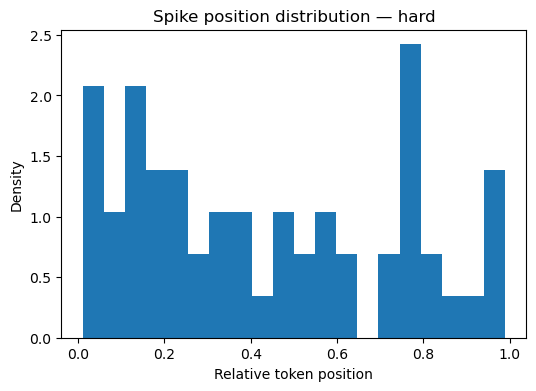

In [32]:
import matplotlib.pyplot as plt

for bucket in ["easy","medium","hard"]:
    g = df2[(df2.bucket == bucket) & (df2.is_spike)]
    plt.figure(figsize=(6,4))
    plt.hist(g["rel_pos"], bins=20, density=True)
    plt.xlabel("Relative token position")
    plt.ylabel("Density")
    plt.title(f"Spike position distribution — {bucket}")
    plt.show()


In [28]:
(df2[df2.is_spike]
 .groupby("bucket")["rel_pos"]
 .agg(["median","mean","count"]))


,median,mean,count
bucket,,,
easy,0.525253,0.490014,88
hard,0.373737,0.430748,59
medium,0.393939,0.441616,75


#### Interpretation: 
Medians: 
- Easy (0.66) : spikes later in generation
- Hard (0.30): earlier/mid reasoning
- Medium (0.59): in between

Hard problems cause early divergence in reasoning trajectories ? 

Let's see what tokens cause spikes

In [29]:
import re

def token_type(tok):
    if re.fullmatch(r"\d+", tok):
        return "number"
    if tok in {"+","-","*","/","=","^"}:
        return "operator"
    if tok.isalpha():
        return "word"
    return "other"

df2["tok_type"] = df2["token_str"].astype(str).map(token_type)


In [30]:
(df2.groupby(["bucket","tok_type"])
   .agg(
       spike_rate=("is_spike","mean"),
       n_tokens=("is_spike","size")
   )
   .sort_values(["bucket","spike_rate"], ascending=[True,False]))


spike_rate  n_tokens
bucket tok_type                      
easy   other       0.017166      4369
       word        0.013333       675
       operator    0.011765        85
       number      0.003444       871
hard   other       0.023789      2312
       word        0.011111       360
       number      0.000000       262
       operator    0.000000        66
medium other       0.014882      4502
       operator    0.008264       121
       word        0.008163       735
       number      0.001558       642